# Source: https://scikit-learn.org/stable/auto_examples/decomposition/plot_image_denoising.html

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import sklearn
import scipy.linalg as LA
import matplotlib.pyplot as plt

from time import time
from sklearn.decomposition import SparseCoder, sparse_encode
from sklearn.linear_model import orthogonal_mp_gram

seed = 42
rng = np.random.default_rng(seed)

## Import test image from scipy

In [2]:
from scipy.datasets import face

raccoon_face = face(gray=True).astype(np.float64)

# normalize
raccoon_face /= 255.0

# downsample for speed
raccoon_face = raccoon_face[::4, ::4] + raccoon_face[2::4, ::4] + raccoon_face[::4, 2::4] + raccoon_face[2::4, 2::4]
raccoon_face /= 4
height, width = raccoon_face.shape

# Distort the right half of the image
print('Distorting image')
distorted = raccoon_face.copy()
distorted[:, width // 2:] += .075 * rng.standard_normal(size=(height, width // 2))

Distorting image


## Display distorted image

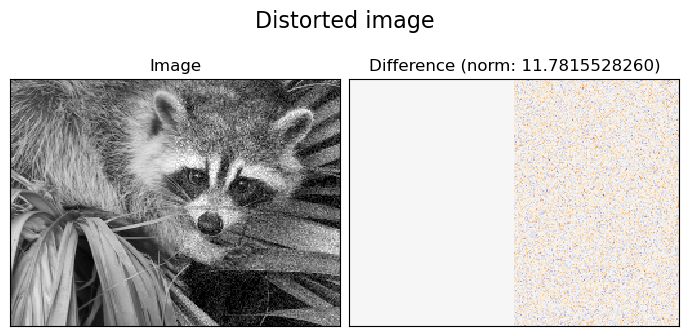

In [3]:
def show_with_diff(image, reference, title):
    plt.figure(figsize=(7, 3.3))
    plt.subplot(1, 2, 1)
    plt.title('Image')
    plt.imshow(image, vmin=0, vmax=1, cmap=plt.cm.gray, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
    
    plt.subplot(1, 2, 2)
    difference = image - reference

    plt.title('Difference (norm: %.10f)' % np.sqrt(np.sum(difference**2)))
    plt.imshow(
        difference, vmin=-0.5, vmax=0.5, cmap=plt.cm.PuOr, interpolation='nearest'
    )
    plt.xticks(())
    plt.yticks(())
    plt.suptitle(title, size=16)
    plt.subplots_adjust(.02, .02, .98, .77, .02, .2)

show_with_diff(distorted, raccoon_face, 'Distorted image')

## Extract reference patches

In [4]:
from time import time
from sklearn.feature_extraction.image import extract_patches_2d

# Extract patches from left half of the image
print('Extracting reference patches')
t0 = time()
patch_size = (7, 7)
data = extract_patches_2d(distorted[:, :width // 2], patch_size)
data = data.reshape(data.shape[0], -1)
data -= np.mean(data, axis=0)
data /= np.std(data, axis=0)
print(f'{data.shape[0]} patches extracted in %.2fs.' % (time() - t0))

Extracting reference patches
22692 patches extracted in 0.01s.


# Import Para_Numba_Approx_V1

In [5]:
import sys
current_dir = os.getcwd()
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(current_dir), '../')))

In [6]:
from Implementations.AK_SVD.Para_Numba_Approx_V1 import OMP, kSVD

In [7]:
import numba
from numba import njit, prange, get_num_threads, get_thread_id
numba.set_num_threads(get_num_threads() // 2)

In [8]:
def plot_log_loss(loss, linestyle='-', alpha = 1):
    plt.semilogy(loss, linestyle=linestyle, alpha = alpha)
    plt.title('Loss vs iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (Log Scale)')
    # plt.show()

## Learn the dictionary from reference patches

### Hyperparams have been set to try to match those in the sklearn example and the results obtained for a more fair comparison!

In [9]:
num_iter = 2
Y = data
T_0 = 1
batch_size = 256
dtype = np.float32

Learning the dictionary
Total Time: 49.59.


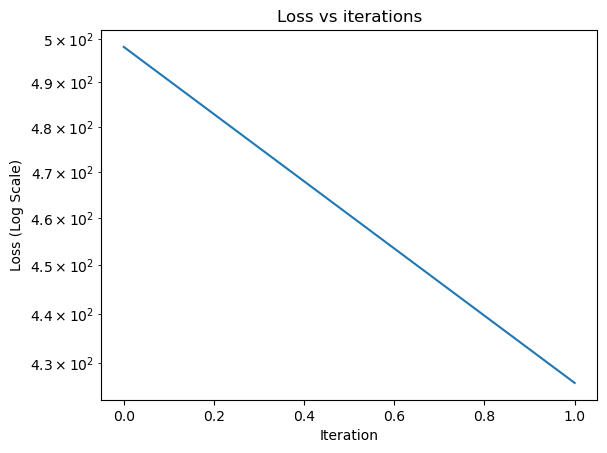

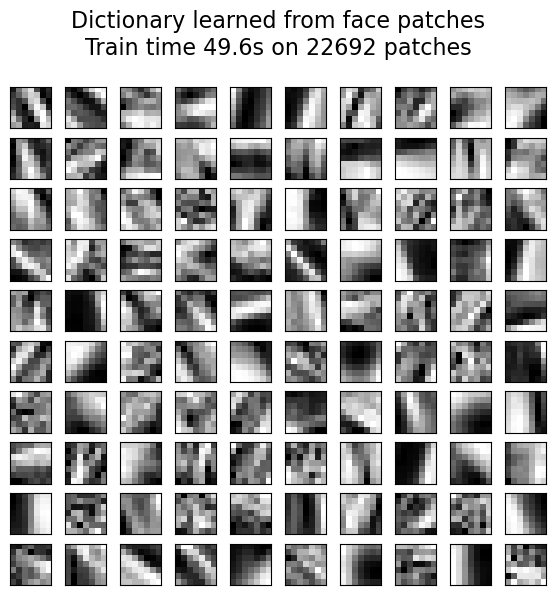

In [10]:
print('Learning the dictionary')
t0 = time()
D, loss = kSVD(Y = Y, 
               T_0 = T_0, 
               k = 300, 
               num_iter = num_iter, 
               verbose=0,
               rng = rng,
               batch_size = batch_size,
               dtype = dtype)
dt = time() - t0
print(f'Total Time: {dt:.2f}.')
plot_log_loss(loss)

plt.figure(figsize=(6.5, 6))
for i, comp in enumerate(D[:100]):
    plt.subplot(10, 10, i+1)
    plt.imshow(comp.reshape(patch_size), cmap=plt.cm.gray_r, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
plt.suptitle(
    'Dictionary learned from face patches\n'
    + 'Train time %.1fs on %d patches' % (dt, len(Y)),
    fontsize=16,
)
plt.subplots_adjust(.08, .02, .92, .85, .08, .23)

## Extract noisy patches and reconstruct them using the dictionary

In [11]:
from sklearn.feature_extraction.image import reconstruct_from_patches_2d

print('Extracting noisy patches...')
t0 = time()
data_test = extract_patches_2d(distorted[:, width // 2 :], patch_size)
data_test = data_test.reshape(data_test.shape[0], -1)
intercept = np.mean(data_test, axis=0)
data_test -= intercept
print('done in %.2fs.' % (time() - t0))

Extracting noisy patches...
done in 0.01s.


OMP
1 atom...
done in 1.82s.
OMP
2 atoms...
done in 3.19s.
Thresholding
 alpha = 0.1...
done in 0.27s.


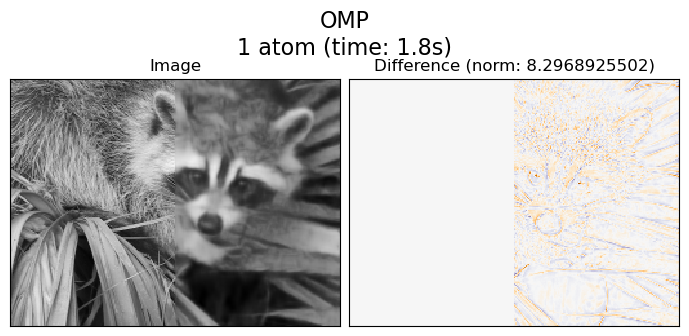

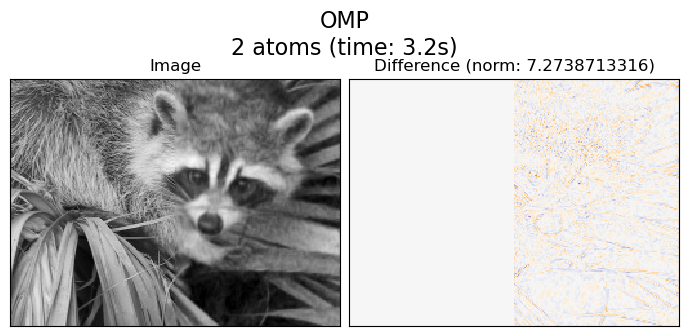

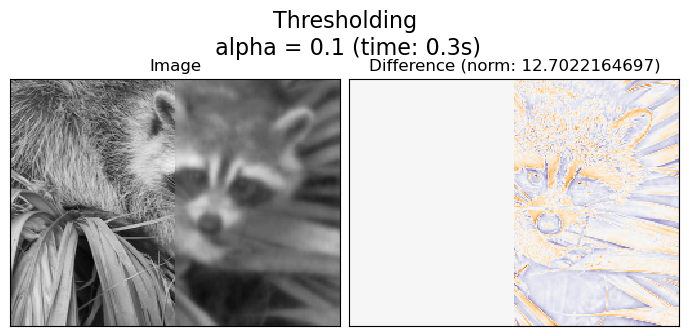

In [12]:
transform_algorithms = [
('OMP\n1 atom', 'omp', {'transform_n_nonzero_coefs': 1}),
('OMP\n2 atoms', 'omp', {'transform_n_nonzero_coefs': 2}),
# ('Lars\n4 atoms', 'lars', {'transform_n_nonzero_coefs': 4}),
('Thresholding\n alpha = 0.1', 'threshold', {'transform_alpha': 0.1}),
]

reconstructions = {}
for title, transform_algorithm, kwargs in transform_algorithms:
    print(title + '...')
    reconstructions[title] = raccoon_face.copy()
    t0 = time()
    coder = SparseCoder(transform_algorithm=transform_algorithm,
                        dictionary = D,
                        **kwargs)
    code = coder.transform(data_test)
    patches = code @ D

    patches += intercept
    patches = patches.reshape(len(data_test), *patch_size)
    if transform_algorithm == 'threshold':
        patches -= patches.min()
        patches /= patches.max()
    reconstructions[title][:, width // 2 :] = reconstruct_from_patches_2d(
        patches, (height, width // 2)
    )
    dt = time() - t0
    print('done in %.2fs.' % dt)
    show_with_diff(reconstructions[title], 
                   raccoon_face, 
                   title + ' (time: %.1fs)' % dt
                  )

plt.show()

## Compare with Custom OMP

Custom OMP
1 atom...
done in 18.29s.
Custom OMP
2 atoms...
done in 0.24s.


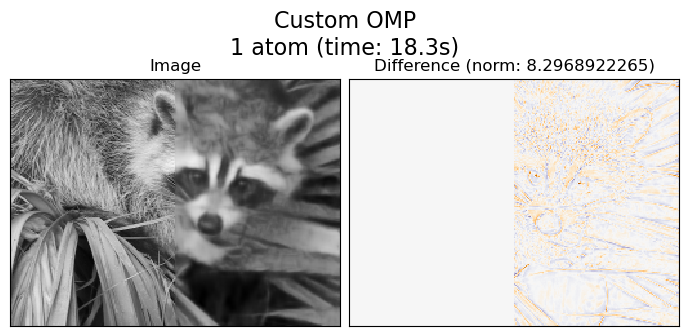

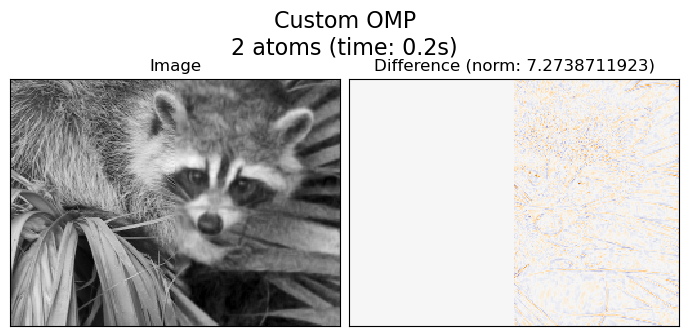

In [13]:
OMP_Params = [
('Custom OMP\n1 atom', {'T_0': 1}),
('Custom OMP\n2 atoms', {'T_0': 2}),
]

reconstructions = {}
data_test2 = data_test.astype(dtype)
for title, kwargs in OMP_Params:
    print(title + '...')
    reconstructions[title] = raccoon_face.copy()
    t0 = time()
    # coder = SparseCoder(transform_algorithm=transform_algorithm,
    #                     dictionary = D,
    #                     **kwargs)
    # code = coder.transform(data_test)
# def OMP(Y, T_0, D, batch_size = 1, rng=42, debug=False, float_dtype=np.float32):
    # D_normalized = D / np.linalg.norm(D, axis = 1, keepdims = True)
    code = OMP(data_test2, kwargs['T_0'], D, batch_size=batch_size, rng=rng, float_dtype=dtype)
    patches = code @ D

    patches += intercept
    patches = patches.reshape(len(data_test), *patch_size)
    # if transform_algorithm == 'threshold':
    #     patches -= patches.min()
    #     patches /= patches.max()
    reconstructions[title][:, width // 2 :] = reconstruct_from_patches_2d(
        patches, (height, width // 2)
    )
    dt = time() - t0
    print('done in %.2fs.' % dt)
    show_with_diff(reconstructions[title], 
                   raccoon_face, 
                   title + ' (time: %.1fs)' % dt
                  )

plt.show()

# Compare with MiniBatchDictionaryLearning used in the scikit-learn example

Learning the dictionary...
1.0 iterations / 101 steps in 33.87.


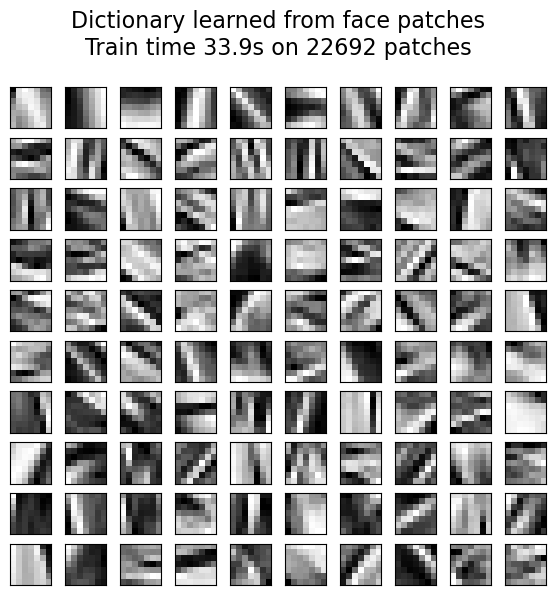

In [14]:
from sklearn.decomposition import MiniBatchDictionaryLearning

print('Learning the dictionary...')
t0 = time()
dico = MiniBatchDictionaryLearning(
    n_components=300,
    batch_size=200,
    alpha=1.0,
    max_iter=10,
    random_state = seed,
)
V = dico.fit(data).components_
dt = time() - t0
print(f'{dico.n_iter_} iterations / {dico.n_steps_} steps in {dt:.2f}.')

plt.figure(figsize=(6.5, 6))
for i, comp in enumerate(V[:100]):
    plt.subplot(10, 10, i+1)
    plt.imshow(comp.reshape(patch_size), cmap=plt.cm.gray_r, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
plt.suptitle(
    'Dictionary learned from face patches\n'
    + 'Train time %.1fs on %d patches' % (dt, len(data)),
    fontsize=16,
)
plt.subplots_adjust(.08, .02, .92, .85, .08, .23)

OMP
1 atom...
done in 1.88s.
OMP
2 atoms...
done in 3.25s.
Thresholding
 alpha = 0.1...
done in 0.31s.


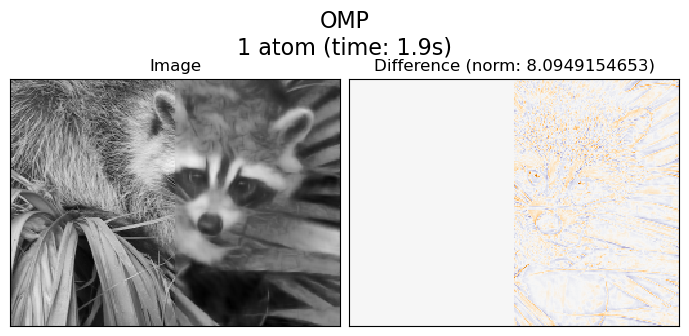

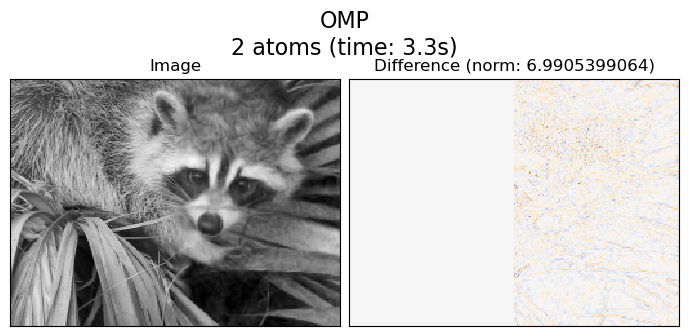

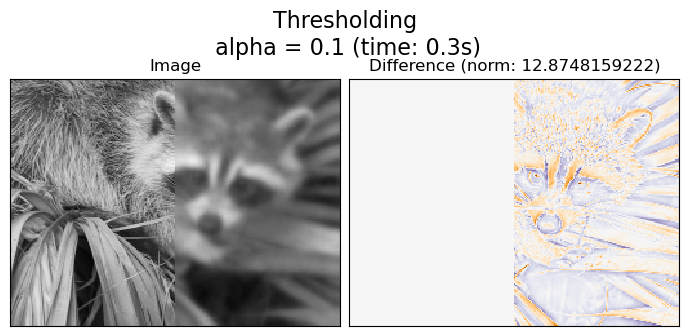

In [15]:
reconstructions = {}
for title, transform_algorithm, kwargs in transform_algorithms:
    print(title + '...')
    reconstructions[title] = raccoon_face.copy()
    t0 = time()
    # coder = SparseCoder(transform_algorithm=transform_algorithm,
    #                     dictionary = D,
    #                     **kwargs)
    # code = coder.transform(data_test)
    # patches = code @ D
    
    dico.set_params(transform_algorithm=transform_algorithm, **kwargs)
    code = dico.transform(data_test)
    patches = np.dot(code, V)
    
    patches += intercept
    patches = patches.reshape(len(data_test), *patch_size)
    if transform_algorithm == 'threshold':
        patches -= patches.min()
        patches /= patches.max()
    reconstructions[title][:, width // 2 :] = reconstruct_from_patches_2d(
        patches, (height, width // 2)
    )
    dt = time() - t0
    print('done in %.2fs.' % dt)
    show_with_diff(reconstructions[title], 
                   raccoon_face, 
                   title + ' (time: %.1fs)' % dt
                  )

plt.show()